# **Continuous latent variables - PCA, PPCA, and Generative Models**

A continuous latent variable answers a hidden geometric question: **which coordinates on a low-dimensional manifold generated this observation?**

This notebook implements:

1. PCA, reconstruction, whitening, and high-dimensional PCA
2. Probabilistic PCA as a linear Gaussian generative model
3. EM for probabilistic PCA and factor analysis
4. Independent component analysis and Kalman filtering
5. ELBO diagnostics, nonlinear latent models, discrete decoder outputs, and dequantization


## Setup

The notebook only needs NumPy and Matplotlib. Everything is implemented from scratch so that the latent-variable mechanics stay visible.


In [1]:
%matplotlib inline
import warnings
import numpy as np
import matplotlib.pyplot as plt

SEED = 20
rng = np.random.default_rng(SEED)
plt.rcParams.update({"figure.figsize": (7, 4.5), "axes.grid": True})


def logsumexp(values, axis=-1, keepdims=False):
    """Stable log(sum(exp(values)))."""
    # Subtract the largest value before exponentiating to avoid overflow.
    maximum = np.max(values, axis=axis, keepdims=True)
    result = maximum + np.log(np.sum(np.exp(values - maximum), axis=axis, keepdims=True))
    # Keep the reduced axis only when the caller needs broadcasting.
    return result if keepdims else np.squeeze(result, axis=axis)


def gaussian_log_density_full(X, mean, covariance):
    """Compute log N(x | mean, covariance) for every row of X."""
    # Cholesky gives covariance = L L.T and avoids forming covariance inverse.
    chol = np.linalg.cholesky(covariance)
    whitened = np.linalg.solve(chol, (X - mean).T).T
    mahalanobis = np.sum(whitened ** 2, axis=1)
    log_determinant = 2 * np.log(np.diag(chol)).sum()
    dim = X.shape[1]
    return -0.5 * (dim * np.log(2 * np.pi) + log_determinant + mahalanobis)


def principal_angles(A, B):
    """Return principal angles in degrees between two column spaces."""
    # QR removes arbitrary scaling from the columns before comparing subspaces.
    QA, _ = np.linalg.qr(A)
    QB, _ = np.linalg.qr(B)
    singular_values = np.linalg.svd(QA.T @ QB, compute_uv=False)
    singular_values = np.clip(singular_values, -1.0, 1.0)
    return np.degrees(np.arccos(singular_values))


def covariance_matrix(X):
    """Sample covariance with the 1/N convention used in the chapter."""
    X_centered = X - X.mean(axis=0)
    return X_centered.T @ X_centered / len(X_centered)


## 1. PCA: a linear continuous latent representation

PCA finds an $M$-dimensional linear subspace inside a $D$-dimensional data space. The retained coordinates are continuous latent variables: they tell us where each observation lies inside the principal subspace.

The same solution can be derived by maximizing projected variance or by minimizing squared reconstruction error.


Explained variance ratio: [0.889 0.106 0.002 0.002 0.001]
Reconstruction error with 2 components: 0.0170


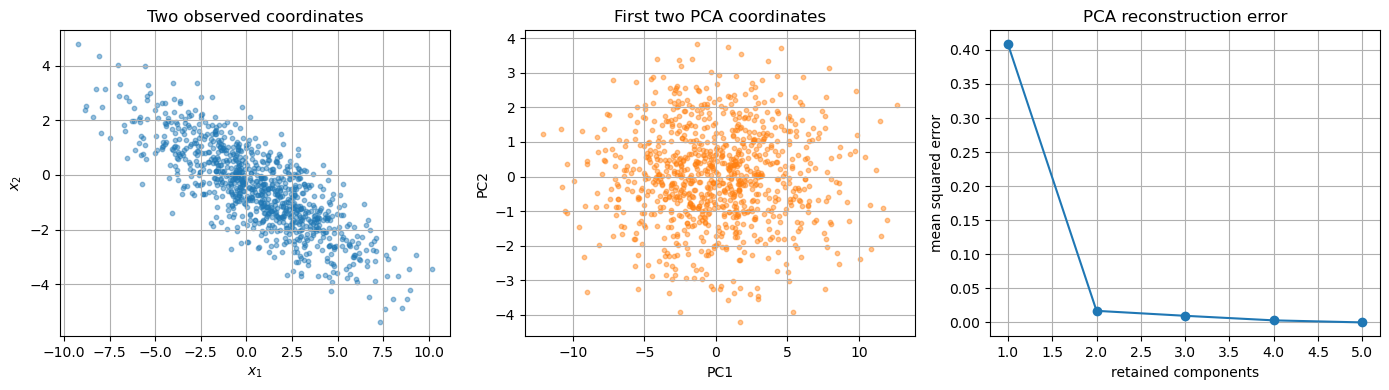

In [2]:
def make_linear_latent_data(generator, n_samples=900):
    """Sample data from a known two-dimensional latent linear model."""
    # The latent coordinates are the hidden low-dimensional causes of variation.
    Z = generator.normal(size=(n_samples, 2))
    Z[:, 0] *= 1.8
    Z[:, 1] *= 0.7

    # W_true maps the latent plane into a five-dimensional observation space.
    W_true = np.array([
        [1.80, 0.25],
        [-0.75, 1.15],
        [0.45, -1.05],
        [1.10, 0.95],
        [0.20, 0.55],
    ])
    mean_true = np.array([0.8, -0.5, 1.2, 0.0, -1.0])
    noise_scale = np.array([0.16, 0.22, 0.18, 0.20, 0.12])

    # Observations are noisy linear images of the latent coordinates.
    X = Z @ W_true.T + mean_true + generator.normal(0.0, noise_scale, size=(n_samples, 5))
    return X, Z, W_true, mean_true


def pca_fit(X, n_components=None):
    """Fit PCA using the covariance eigendecomposition."""
    n_samples, n_features = X.shape
    if n_components is None:
        n_components = n_features

    mean = X.mean(axis=0)
    X_centered = X - mean
    covariance = X_centered.T @ X_centered / n_samples

    # The covariance is symmetric, so eigh is more stable than eig.
    eigenvalues, eigenvectors = np.linalg.eigh(covariance)
    # Sort from largest to smallest variance direction.
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    return {
        "mean": mean,
        "components": eigenvectors[:, :n_components],
        "eigenvalues": eigenvalues,
        "explained_variance_ratio": eigenvalues / eigenvalues.sum(),
        "covariance": covariance,
    }


def pca_transform(model, X, n_components=None):
    """Project observations into the PCA coordinate system."""
    components = model["components"] if n_components is None else model["components"][:, :n_components]
    return (X - model["mean"]) @ components


def pca_reconstruct(model, scores):
    """Map PCA coordinates back into data space."""
    components = model["components"][:, :scores.shape[1]]
    return scores @ components.T + model["mean"]


X, Z_true, W_true, mean_true = make_linear_latent_data(rng)
pca = pca_fit(X)
scores_2d = pca_transform(pca, X, n_components=2)

reconstruction_errors = []
for m in range(1, X.shape[1] + 1):
    scores_m = pca_transform(pca, X, n_components=m)
    X_reconstructed = pca_reconstruct(pca, scores_m)
    reconstruction_errors.append(np.mean((X - X_reconstructed) ** 2))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.45)
axes[0].set(title="Two observed coordinates", xlabel="$x_1$", ylabel="$x_2$")
axes[1].scatter(scores_2d[:, 0], scores_2d[:, 1], s=10, alpha=0.45, color="tab:orange")
axes[1].set(title="First two PCA coordinates", xlabel="PC1", ylabel="PC2")
axes[2].plot(range(1, X.shape[1] + 1), reconstruction_errors, marker="o")
axes[2].set(title="PCA reconstruction error", xlabel="retained components", ylabel="mean squared error")
plt.tight_layout()

print("Explained variance ratio:", np.round(pca["explained_variance_ratio"], 3))
print("Reconstruction error with 2 components:", f"{reconstruction_errors[1]:.4f}")

### Whitening

Standardization makes each observed coordinate have unit variance. Whitening goes further: it rotates into the PCA basis and rescales every principal direction so that the covariance becomes the identity matrix.


Whitened covariance, rounded:
[[ 1.  0.  0.  0.  0.]
 [ 0.  1.  0.  0. -0.]
 [ 0.  0.  1. -0. -0.]
 [ 0.  0. -0.  1.  0.]
 [ 0. -0. -0.  0.  1.]]


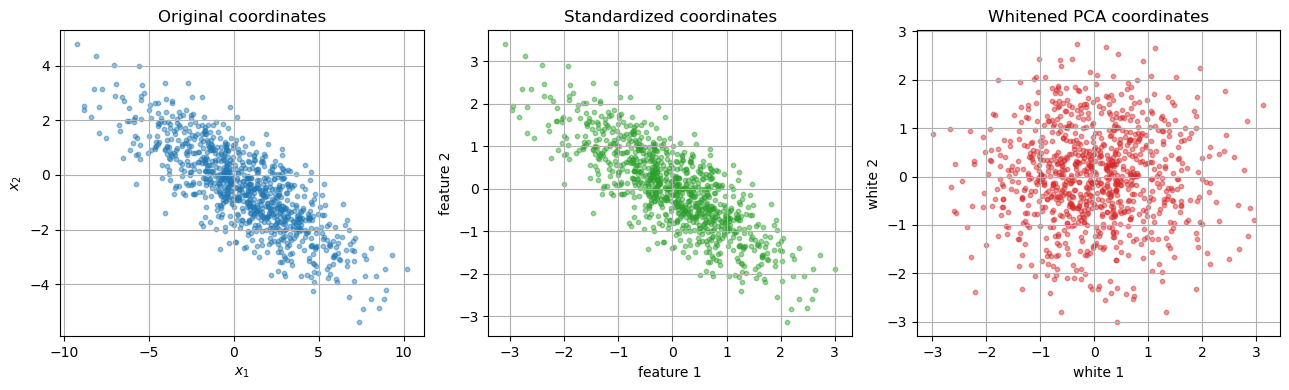

In [3]:
def standardize(X, eps=1e-12):
    """Center each feature and scale it to unit standard deviation."""
    return (X - X.mean(axis=0)) / (X.std(axis=0) + eps)


def pca_whiten(X, eps=1e-12):
    """Transform data to zero mean and identity covariance."""
    model = pca_fit(X)
    # Full PCA scores have diagonal covariance equal to the eigenvalues.
    scores = pca_transform(model, X)
    whitened = scores / np.sqrt(model["eigenvalues"] + eps)
    return whitened, model


X_standardized = standardize(X)
X_whitened, whitening_model = pca_whiten(X)
white_covariance = covariance_matrix(X_whitened)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(X[:, 0], X[:, 1], s=10, alpha=0.45)
axes[0].set(title="Original coordinates", xlabel="$x_1$", ylabel="$x_2$")
axes[1].scatter(X_standardized[:, 0], X_standardized[:, 1], s=10, alpha=0.45, color="tab:green")
axes[1].set(title="Standardized coordinates", xlabel="feature 1", ylabel="feature 2")
axes[2].scatter(X_whitened[:, 0], X_whitened[:, 1], s=10, alpha=0.45, color="tab:red")
axes[2].set(title="Whitened PCA coordinates", xlabel="white 1", ylabel="white 2")
plt.tight_layout()

print("Whitened covariance, rounded:")
print(np.round(white_covariance, 2))

### High-dimensional PCA with the dual trick

When $D$ is large and $N < D$, it is cheaper to diagonalize the $N \times N$ Gram matrix $X X^T / N$ than the $D \times D$ covariance matrix $X^T X / N$. The recovered eigenvectors live in the original data space.


In [4]:
def dual_pca_fit(X, n_components, eps=1e-12):
    """Fit PCA through the N by N Gram matrix instead of the D by D covariance."""
    n_samples = len(X)
    mean = X.mean(axis=0)
    X_centered = X - mean

    # The Gram matrix shares the non-zero eigenvalues of the covariance matrix.
    gram = X_centered @ X_centered.T / n_samples
    eigenvalues, gram_vectors = np.linalg.eigh(gram)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    gram_vectors = gram_vectors[:, order]

    keep = eigenvalues[:n_components] > eps
    eigenvalues = eigenvalues[:n_components][keep]
    gram_vectors = gram_vectors[:, :n_components][:, keep]

    # Map each Gram eigenvector back to the original D-dimensional feature space.
    components = X_centered.T @ gram_vectors / np.sqrt(n_samples * eigenvalues)
    components = components / np.linalg.norm(components, axis=0, keepdims=True)
    return {"mean": mean, "components": components, "eigenvalues": eigenvalues}


n_samples_hd, n_features_hd, n_latent_hd = 80, 300, 6
latent_hd = rng.normal(size=(n_samples_hd, n_latent_hd))
random_basis, _ = np.linalg.qr(rng.normal(size=(n_features_hd, n_latent_hd)))
scales_hd = np.linspace(4.0, 0.8, n_latent_hd)
X_hd = latent_hd @ np.diag(scales_hd) @ random_basis.T
X_hd += 0.05 * rng.normal(size=(n_samples_hd, n_features_hd))

direct_hd = pca_fit(X_hd, n_components=n_latent_hd)
dual_hd = dual_pca_fit(X_hd, n_components=n_latent_hd)
angles_hd = principal_angles(direct_hd["components"], dual_hd["components"])

print("Principal angles between direct and dual PCA subspaces:")
print(np.round(angles_hd, 8))

Principal angles between direct and dual PCA subspaces:
[0.00e+00 0.00e+00 0.00e+00 1.48e-06 2.26e-06 2.56e-06]


## 2. Probabilistic PCA

Probabilistic PCA defines a generative model:

$$z \sim N(0, I), \qquad x \mid z \sim N(Wz + \mu, \sigma^2 I).$$

After integrating out $z$, the marginal distribution is Gaussian with covariance $C = W W^T + \sigma^2 I$. The latent coordinates are continuous and the model can both infer them and sample new observations.


ML sigma^2: 0.0283
PPCA reconstruction MSE: 0.0171
PPCA log likelihood: -3134.24


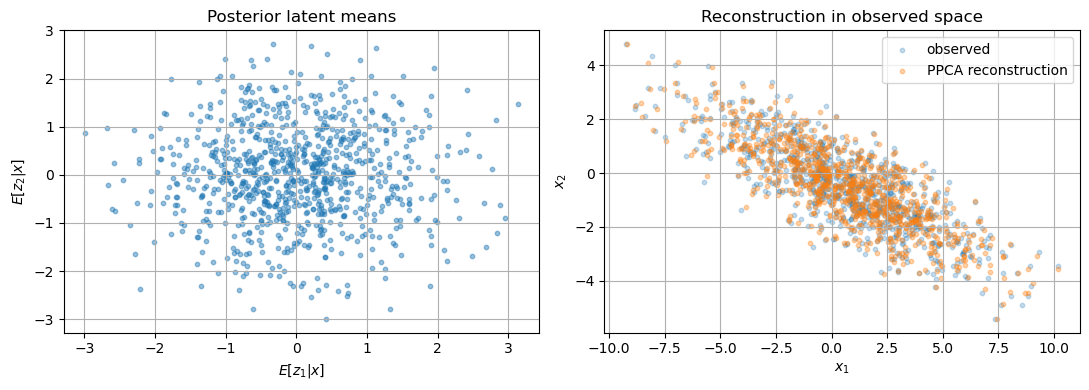

In [5]:
def ppca_closed_form(X, n_components, rotation=None):
    """Closed-form maximum-likelihood PPCA solution from the PCA spectrum."""
    model = pca_fit(X)
    eigenvalues = model["eigenvalues"]
    components = model["components"][:, :n_components]

    # The ML noise is the average variance in the discarded directions.
    if n_components < X.shape[1]:
        sigma2 = np.mean(eigenvalues[n_components:])
    else:
        sigma2 = 1e-8

    # Each loading column is a principal direction scaled by explained variance.
    loading_scales = np.sqrt(np.maximum(eigenvalues[:n_components] - sigma2, 0.0))
    W = components * loading_scales[None, :]

    # Any orthogonal latent rotation leaves W W.T unchanged.
    if rotation is not None:
        W = W @ rotation

    return {"mean": model["mean"], "W": W, "sigma2": sigma2, "pca": model}


def ppca_posterior_mean(X, mean, W, sigma2):
    """Return E[z | x] for every observation under PPCA."""
    latent_dim = W.shape[1]
    M = W.T @ W + sigma2 * np.eye(latent_dim)
    # Row form of M^{-1} W.T (x - mean): X_centered @ W @ M^{-1}.
    return (X - mean) @ W @ np.linalg.inv(M)


def ppca_log_likelihood(X, mean, W, sigma2):
    """Evaluate the incomplete-data log likelihood log p(X)."""
    covariance = W @ W.T + sigma2 * np.eye(W.shape[0])
    return gaussian_log_density_full(X, mean, covariance).sum()


ppca = ppca_closed_form(X, n_components=2)
Z_ppca = ppca_posterior_mean(X, ppca["mean"], ppca["W"], ppca["sigma2"])
X_ppca_reconstructed = Z_ppca @ ppca["W"].T + ppca["mean"]
ppca_mse = np.mean((X - X_ppca_reconstructed) ** 2)
ppca_ll = ppca_log_likelihood(X, ppca["mean"], ppca["W"], ppca["sigma2"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(Z_ppca[:, 0], Z_ppca[:, 1], s=10, alpha=0.45)
axes[0].set(title="Posterior latent means", xlabel="$E[z_1 | x]$", ylabel="$E[z_2 | x]$")
axes[1].scatter(X[:, 0], X[:, 1], s=10, alpha=0.25, label="observed")
axes[1].scatter(X_ppca_reconstructed[:, 0], X_ppca_reconstructed[:, 1], s=10, alpha=0.35, label="PPCA reconstruction")
axes[1].set(title="Reconstruction in observed space", xlabel="$x_1$", ylabel="$x_2$")
axes[1].legend()
plt.tight_layout()

print(f"ML sigma^2: {ppca['sigma2']:.4f}")
print(f"PPCA reconstruction MSE: {ppca_mse:.4f}")
print(f"PPCA log likelihood: {ppca_ll:.2f}")

### Rotational non-identifiability

The marginal distribution depends on $W$ only through $W W^T$. If $R$ is orthogonal, then $W R$ defines the same distribution over $x$. The latent coordinate system rotates, but the generated data distribution does not change.


In [6]:
theta = 0.85
rotation = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta), np.cos(theta)],
])

W_rotated = ppca["W"] @ rotation
covariance_difference = np.linalg.norm(ppca["W"] @ ppca["W"].T - W_rotated @ W_rotated.T)
ll_rotated = ppca_log_likelihood(X, ppca["mean"], W_rotated, ppca["sigma2"])

Z_rotated = ppca_posterior_mean(X, ppca["mean"], W_rotated, ppca["sigma2"])
X_rotated_reconstructed = Z_rotated @ W_rotated.T + ppca["mean"]
reconstruction_difference = np.max(np.abs(X_ppca_reconstructed - X_rotated_reconstructed))

print(f"||W W.T - W_rot W_rot.T|| = {covariance_difference:.3e}")
print(f"log likelihood difference = {abs(ppca_ll - ll_rotated):.3e}")
print(f"max reconstruction difference = {reconstruction_difference:.3e}")


||W W.T - W_rot W_rot.T|| = 4.080e-15
log likelihood difference = 8.185e-12
max reconstruction difference = 4.441e-15


### Ancestral sampling from PPCA

PPCA is a density model, not only a dimensionality reducer. Sampling follows the generative story directly: draw $z$, map it through $Wz + \mu$, then add isotropic Gaussian noise.


Relative covariance error from finite sampling: 0.026


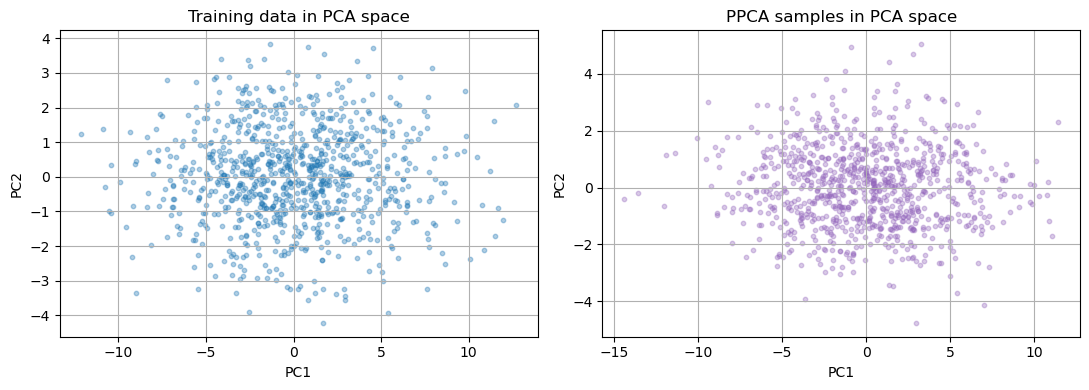

In [7]:
def sample_ppca(generator, n_samples, mean, W, sigma2):
    """Generate observations from the PPCA model."""
    # The prior over latent coordinates is standard normal.
    Z = generator.normal(size=(n_samples, W.shape[1]))
    # Conditional noise fills directions not explained by the latent plane.
    noise = generator.normal(0.0, np.sqrt(sigma2), size=(n_samples, W.shape[0]))
    X_sampled = Z @ W.T + mean + noise
    return X_sampled, Z


X_generated, Z_generated = sample_ppca(rng, len(X), ppca["mean"], ppca["W"], ppca["sigma2"])
training_scores = pca_transform(pca, X, n_components=2)
generated_scores = pca_transform(pca, X_generated, n_components=2)

training_covariance = covariance_matrix(X)
generated_covariance = covariance_matrix(X_generated)
relative_covariance_error = np.linalg.norm(training_covariance - generated_covariance) / np.linalg.norm(training_covariance)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(training_scores[:, 0], training_scores[:, 1], s=10, alpha=0.35)
axes[0].set(title="Training data in PCA space", xlabel="PC1", ylabel="PC2")
axes[1].scatter(generated_scores[:, 0], generated_scores[:, 1], s=10, alpha=0.35, color="tab:purple")
axes[1].set(title="PPCA samples in PCA space", xlabel="PC1", ylabel="PC2")
plt.tight_layout()

print(f"Relative covariance error from finite sampling: {relative_covariance_error:.3f}")


## 3. EM for probabilistic PCA

Even though PPCA has a closed-form maximum-likelihood solution, EM is useful because the E-step only needs expectations of the continuous latent variables. This same pattern later becomes the ELBO logic behind VAEs.


Principal angles to closed-form PPCA subspace: [0. 0.]
EM iterations: 200


<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/var/folders/q2/c_0y_0yj6nqg6pjrqy90sshc0000gn/T/ipykernel_81383/3544958431.py:48: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set(title="Estimated residual variance", ylabel="$\sigma^2$")


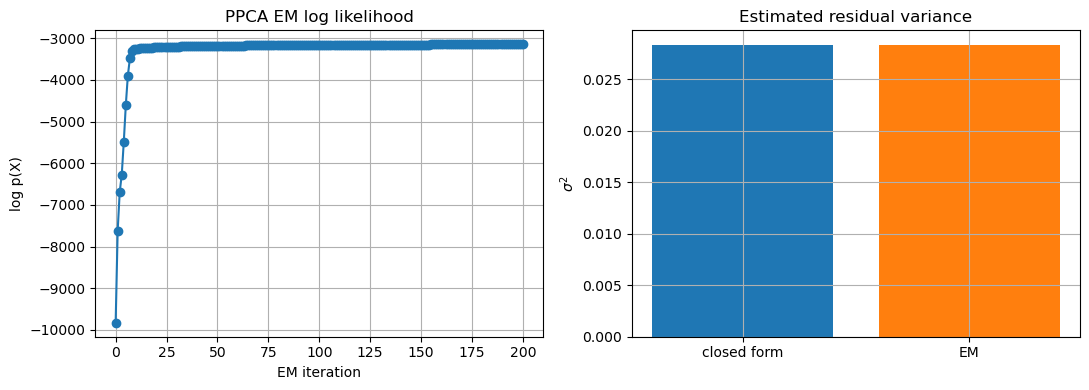

In [8]:
def ppca_em(X, n_components, *, seed=0, max_iter=200, tolerance=1e-7):
    """Estimate PPCA parameters with the EM algorithm."""
    generator = np.random.default_rng(seed)
    n_samples, n_features = X.shape
    mean = X.mean(axis=0)
    X_centered = X - mean

    # Random small loadings break symmetry between latent dimensions.
    W = 0.5 * generator.normal(size=(n_features, n_components))
    # Start with a broad isotropic residual variance.
    sigma2 = 0.5 * np.mean(np.var(X_centered, axis=0))
    history = [ppca_log_likelihood(X, mean, W, sigma2)]

    for _ in range(max_iter):
        M = W.T @ W + sigma2 * np.eye(n_components)
        inv_M = np.linalg.inv(M)

        # E-step: posterior means and second moments of z_n.
        Ez = X_centered @ W @ inv_M
        Ezz_sum = n_samples * sigma2 * inv_M + Ez.T @ Ez

        # M-step: regress centered observations on expected latent coordinates.
        W_new = X_centered.T @ Ez @ np.linalg.inv(Ezz_sum)

        # Update sigma2 using the expected squared reconstruction residual.
        total_data_energy = np.sum(X_centered ** 2)
        cross_term = np.sum((X_centered @ W_new) * Ez)
        model_term = np.trace(Ezz_sum @ (W_new.T @ W_new))
        sigma2_new = (total_data_energy - 2 * cross_term + model_term) / (n_samples * n_features)
        sigma2_new = max(float(sigma2_new), 1e-10)

        W, sigma2 = W_new, sigma2_new
        history.append(ppca_log_likelihood(X, mean, W, sigma2))

        if history[-1] - history[-2] < tolerance:
            break

    return {"mean": mean, "W": W, "sigma2": sigma2, "history": np.asarray(history)}


ppca_em_fit = ppca_em(X, 2, seed=SEED)
em_angles = principal_angles(ppca_em_fit["W"], ppca["W"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ppca_em_fit["history"], marker="o")
axes[0].set(title="PPCA EM log likelihood", xlabel="EM iteration", ylabel="log p(X)")
axes[1].bar(["closed form", "EM"], [ppca["sigma2"], ppca_em_fit["sigma2"]], color=["tab:blue", "tab:orange"])
axes[1].set(title="Estimated residual variance", ylabel="$\sigma^2$")
plt.tight_layout()

print("Principal angles to closed-form PPCA subspace:", np.round(em_angles, 4))
print(f"EM iterations: {len(ppca_em_fit['history']) - 1}")


## 4. Factor analysis

Factor analysis replaces PPCA's isotropic residual noise $\sigma^2 I$ with a diagonal covariance $\Psi$. This lets each observed dimension have its own uniqueness, while shared latent factors still explain correlations.


True psi:      [0.03 0.25 0.08 0.45 0.15]
Estimated psi: [0.052 0.24  0.063 0.376 0.16 ]


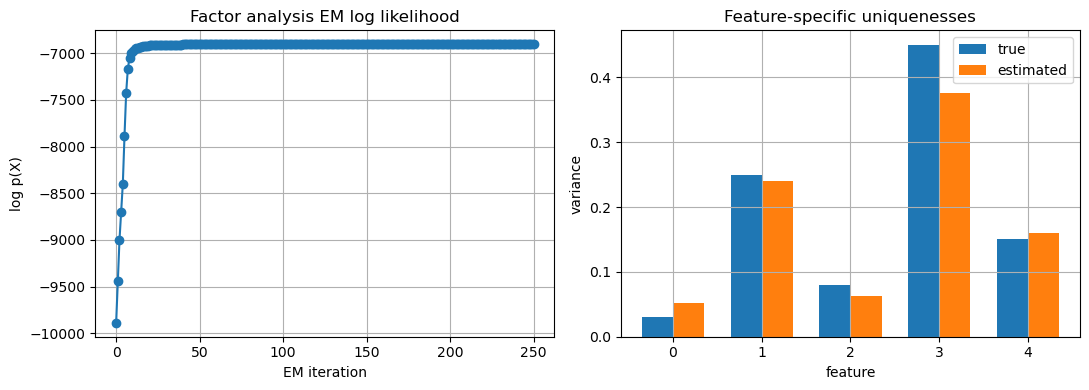

In [9]:
def make_factor_analysis_data(generator, n_samples=1200):
    """Generate data with shared factors plus feature-specific noise."""
    Z = generator.normal(size=(n_samples, 2))
    W = np.array([
        [1.45, 0.10],
        [0.80, -0.65],
        [-0.25, 1.10],
        [1.05, 0.55],
        [0.15, -0.95],
    ])
    psi = np.array([0.03, 0.25, 0.08, 0.45, 0.15])
    mean = np.array([0.2, -0.3, 0.4, 0.0, -0.2])
    X_fa = Z @ W.T + mean + generator.normal(0.0, np.sqrt(psi), size=(n_samples, len(psi)))
    return X_fa, W, psi, mean


def factor_analysis_log_likelihood(X, mean, W, psi):
    """Evaluate log p(X) under a factor-analysis marginal Gaussian."""
    covariance = W @ W.T + np.diag(psi)
    return gaussian_log_density_full(X, mean, covariance).sum()


def factor_analysis_em(X, n_factors, *, seed=0, max_iter=250, tolerance=1e-7, min_psi=1e-6):
    """Estimate factor analysis parameters with EM."""
    generator = np.random.default_rng(seed)
    n_samples, n_features = X.shape
    mean = X.mean(axis=0)
    X_centered = X - mean
    S = X_centered.T @ X_centered / n_samples

    W = 0.3 * generator.normal(size=(n_features, n_factors))
    psi = np.maximum(np.diag(S), min_psi)
    history = [factor_analysis_log_likelihood(X, mean, W, psi)]

    for _ in range(max_iter):
        # Multiplying rows of W by psi_inv is equivalent to diag(psi_inv) @ W.
        psi_inv = 1.0 / psi
        G = np.linalg.inv(np.eye(n_factors) + W.T @ (psi_inv[:, None] * W))

        # E-step: infer factor posterior moments under diagonal observation noise.
        Ez = (X_centered * psi_inv) @ W @ G
        Ezz_sum = n_samples * G + Ez.T @ Ez

        # M-step: update loadings from expected sufficient statistics.
        W_new = X_centered.T @ Ez @ np.linalg.inv(Ezz_sum)
        cross = Ez.T @ X_centered / n_samples
        psi_new = np.diag(S - W_new @ cross)
        psi_new = np.maximum(psi_new, min_psi)

        W, psi = W_new, psi_new
        history.append(factor_analysis_log_likelihood(X, mean, W, psi))

        if history[-1] - history[-2] < tolerance:
            break

    return {"mean": mean, "W": W, "psi": psi, "history": np.asarray(history)}


X_fa, W_fa_true, psi_true, mean_fa_true = make_factor_analysis_data(rng)
fa_fit = factor_analysis_em(X_fa, 2, seed=SEED)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(fa_fit["history"], marker="o")
axes[0].set(title="Factor analysis EM log likelihood", xlabel="EM iteration", ylabel="log p(X)")
width = 0.35
feature_ids = np.arange(len(psi_true))
axes[1].bar(feature_ids - width / 2, psi_true, width, label="true")
axes[1].bar(feature_ids + width / 2, fa_fit["psi"], width, label="estimated")
axes[1].set(title="Feature-specific uniquenesses", xlabel="feature", ylabel="variance")
axes[1].legend()
plt.tight_layout()

print("True psi:     ", np.round(psi_true, 3))
print("Estimated psi:", np.round(fa_fit["psi"], 3))
assert np.all(np.diff(fa_fit["history"]) >= -1e-5)


## 5. Independent component analysis

PCA decorrelates coordinates, but uncorrelated Gaussian coordinates are still rotationally ambiguous. ICA adds a non-Gaussian assumption and tries to recover statistically independent sources from observed mixtures.


Absolute source/recovery correlations:
[[1.    0.016]
 [0.027 1.   ]]


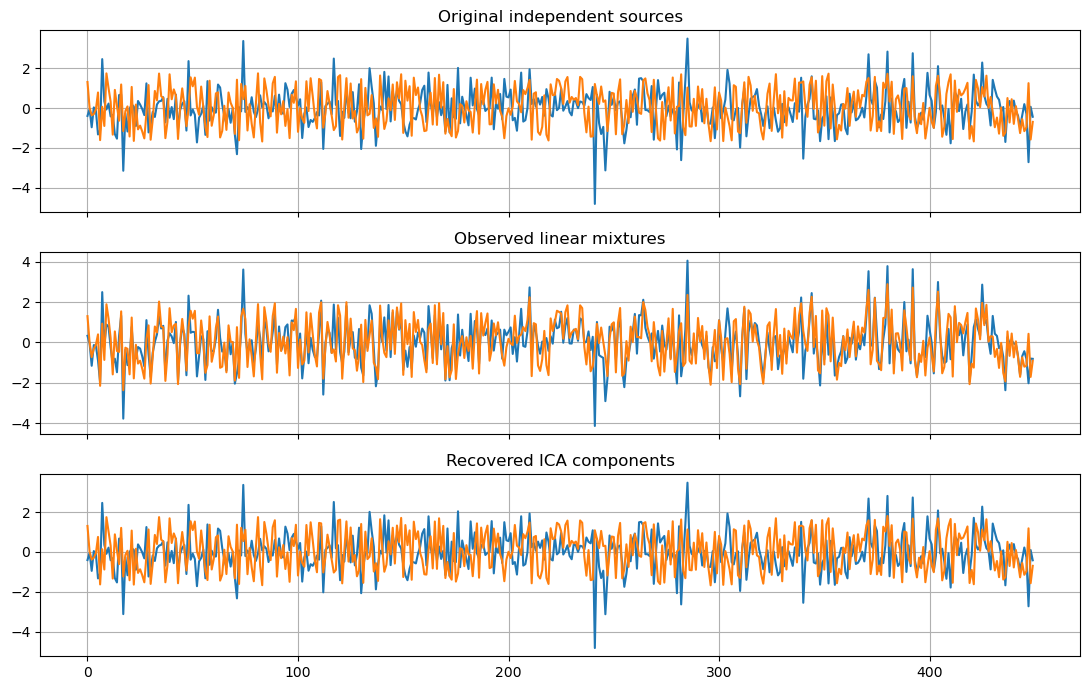

In [10]:
def make_ica_signals(n_samples=1600, seed=0):
    """Create two independent non-Gaussian source signals and mix them."""
    generator = np.random.default_rng(seed)
    # ICA needs statistical independence, not just low correlation.
    # Independent random sources are a cleaner demo than two waveforms sharing time.
    source_1 = generator.laplace(0.0, 1.0, size=n_samples)
    source_2 = generator.uniform(-np.sqrt(3), np.sqrt(3), size=n_samples)
    sources = np.column_stack([source_1, source_2])
    sources = standardize(sources)

    mixing = np.array([[1.0, 0.55], [0.35, 1.10]])
    mixtures = sources @ mixing.T
    return sources, mixtures, mixing


def whiten_for_ica(X, n_components, eps=1e-12):
    """Center and whiten data before the ICA fixed-point iteration."""
    model = pca_fit(X, n_components=n_components)
    scores = pca_transform(model, X, n_components=n_components)
    whitened = scores / np.sqrt(model["eigenvalues"][:n_components] + eps)
    return whitened, model


def symmetric_decorrelation(W):
    """Force rows of W to stay orthonormal."""
    # FastICA needs a valid unmixing rotation after every fixed-point update.
    eigenvalues, eigenvectors = np.linalg.eigh(W @ W.T)
    return eigenvectors @ np.diag(1.0 / np.sqrt(eigenvalues)) @ eigenvectors.T @ W


def fastica(X, n_components, *, seed=0, max_iter=500, tolerance=1e-6):
    """FastICA with tanh nonlinearity and symmetric decorrelation."""
    generator = np.random.default_rng(seed)
    X_white, whitening_model = whiten_for_ica(X, n_components)
    W, _ = np.linalg.qr(generator.normal(size=(n_components, n_components)))

    for _ in range(max_iter):
        projected = X_white @ W.T
        g = np.tanh(projected)
        g_prime = 1.0 - g ** 2

        # Fixed-point update for non-Gaussian independent directions.
        W_new = g.T @ X_white / len(X_white) - np.diag(g_prime.mean(axis=0)) @ W
        W_new = symmetric_decorrelation(W_new)

        # Sign and permutation are not identifiable, so convergence uses abs dots.
        alignment = np.abs(np.diag(W_new @ W.T))
        if 1.0 - alignment.min() < tolerance:
            W = W_new
            break
        W = W_new

    recovered = X_white @ W.T
    return recovered, W, whitening_model


sources, mixtures, mixing = make_ica_signals(seed=SEED)
recovered, unmixing, ica_whitening = fastica(mixtures, 2, seed=SEED)
correlations = np.corrcoef(sources.T, recovered.T)[:2, 2:]
best_abs_correlations = np.max(np.abs(correlations), axis=1)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
window = slice(0, 450)
axes[0].plot(sources[window]); axes[0].set_title("Original independent sources")
axes[1].plot(mixtures[window]); axes[1].set_title("Observed linear mixtures")
axes[2].plot(recovered[window]); axes[2].set_title("Recovered ICA components")
plt.tight_layout()

print("Absolute source/recovery correlations:")
print(np.round(np.abs(correlations), 3))
assert best_abs_correlations.mean() > 0.95


## 6. Kalman filtering

Kalman filters extend continuous latent-variable models to sequences. The latent state is continuous and Markovian, and each observation is a noisy linear measurement of the current latent state.


Observation RMSE: 0.426
Filtered RMSE:    0.192


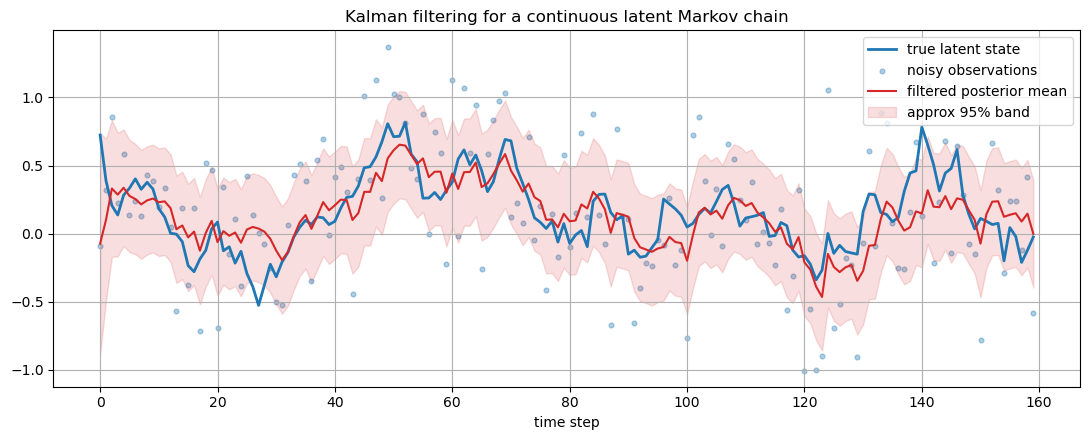

In [11]:
def simulate_linear_dynamical_system(generator, n_steps=160):
    """Simulate a one-dimensional latent state and noisy observations."""
    transition = 0.93
    process_variance = 0.12 ** 2
    observation_scale = 1.0
    observation_variance = 0.45 ** 2

    z = np.zeros(n_steps)
    x = np.zeros(n_steps)
    z[0] = generator.normal(0.0, 1.0)
    x[0] = observation_scale * z[0] + generator.normal(0.0, np.sqrt(observation_variance))

    for t in range(1, n_steps):
        z[t] = transition * z[t - 1] + generator.normal(0.0, np.sqrt(process_variance))
        x[t] = observation_scale * z[t] + generator.normal(0.0, np.sqrt(observation_variance))

    params = {
        "transition": transition,
        "process_variance": process_variance,
        "observation_scale": observation_scale,
        "observation_variance": observation_variance,
    }
    return z, x, params


def kalman_filter_1d(observations, transition, observation_scale, process_variance, observation_variance, m0=0.0, p0=1.0):
    """Run the scalar Kalman filter recursions."""
    means = np.empty_like(observations)
    variances = np.empty_like(observations)
    mean, variance = m0, p0

    for t, observation in enumerate(observations):
        # Predict the next latent state using the Markov transition model.
        predicted_mean = transition * mean
        predicted_variance = transition ** 2 * variance + process_variance

        # Update with the new observation using the Kalman gain.
        innovation_variance = observation_scale ** 2 * predicted_variance + observation_variance
        kalman_gain = predicted_variance * observation_scale / innovation_variance
        mean = predicted_mean + kalman_gain * (observation - observation_scale * predicted_mean)
        variance = (1.0 - kalman_gain * observation_scale) * predicted_variance

        means[t] = mean
        variances[t] = variance

    return means, variances


z_true, observations, kf_params = simulate_linear_dynamical_system(rng)
filtered_mean, filtered_variance = kalman_filter_1d(observations, **kf_params)
filtered_rmse = np.sqrt(np.mean((filtered_mean - z_true) ** 2))
raw_rmse = np.sqrt(np.mean((observations - z_true) ** 2))

time = np.arange(len(observations))
plt.figure(figsize=(11, 4.5))
plt.plot(time, z_true, label="true latent state", lw=2)
plt.scatter(time, observations, s=12, alpha=0.35, label="noisy observations")
plt.plot(time, filtered_mean, label="filtered posterior mean", color="tab:red")
std = np.sqrt(filtered_variance)
plt.fill_between(time, filtered_mean - 2 * std, filtered_mean + 2 * std, color="tab:red", alpha=0.15, label="approx 95% band")
plt.title("Kalman filtering for a continuous latent Markov chain")
plt.xlabel("time step")
plt.legend(loc="upper right")
plt.tight_layout()

print(f"Observation RMSE: {raw_rmse:.3f}")
print(f"Filtered RMSE:    {filtered_rmse:.3f}")

## 7. ELBO identity for a continuous latent variable

For any distribution $q(z)$,

$$\log p(x) = L(q, w) + KL(q(z) || p(z | x, w)).$$

The ELBO $L(q,w)$ is a lower bound because the KL divergence is non-negative. The example below verifies the identity analytically for a one-dimensional linear Gaussian model.


In [12]:
def normal_logpdf_scalar(x, mean, variance):
    """Scalar Gaussian log density."""
    return -0.5 * (np.log(2 * np.pi * variance) + (x - mean) ** 2 / variance)


def normal_kl_scalar(mean_q, var_q, mean_p, var_p):
    """KL(N_q || N_p) for scalar Gaussians."""
    return 0.5 * (np.log(var_p / var_q) + (var_q + (mean_q - mean_p) ** 2) / var_p - 1.0)


x0 = 1.35
w = 1.8
mu = -0.2
sigma2 = 0.35 ** 2

# In this linear Gaussian model, p(x) and p(z | x) are available in closed form.
prior_variance = 1.0
evidence_variance = w ** 2 * prior_variance + sigma2
log_evidence = normal_logpdf_scalar(x0, mu, evidence_variance)
posterior_variance = 1.0 / (1.0 + w ** 2 / sigma2)
posterior_mean = posterior_variance * w * (x0 - mu) / sigma2

# Pick a deliberately imperfect variational distribution q(z).
q_mean = posterior_mean + 0.45
q_variance = posterior_variance * 2.4

expected_z2 = q_variance + q_mean ** 2
expected_residual2 = (x0 - mu) ** 2 - 2 * w * (x0 - mu) * q_mean + w ** 2 * expected_z2
expected_log_prior = -0.5 * (np.log(2 * np.pi) + expected_z2)
expected_log_likelihood = -0.5 * (np.log(2 * np.pi * sigma2) + expected_residual2 / sigma2)
entropy_q = 0.5 * (1.0 + np.log(2 * np.pi * q_variance))
elbo = expected_log_prior + expected_log_likelihood + entropy_q
kl_to_posterior = normal_kl_scalar(q_mean, q_variance, posterior_mean, posterior_variance)

print(f"log p(x):          {log_evidence:.6f}")
print(f"ELBO:              {elbo:.6f}")
print(f"KL to posterior:   {kl_to_posterior:.6f}")
print(f"ELBO + KL:         {elbo + kl_to_posterior:.6f}")


log p(x):          -1.882530
ELBO:              -4.924005
KL to posterior:   3.041475
ELBO + KL:         -1.882530


## 8. Nonlinear latent-variable models

A neural decoder replaces the linear map $Wz + \mu$ with a nonlinear map $g(z,w)$. Sampling stays easy, but likelihood becomes an integral over latent space:

$$p(x) = \int p(z) p(x | z) dz.$$

The Monte Carlo approximation below shows why likelihood evaluation can become expensive when only a small fraction of latent samples explain a given observation.


Rows are sample sizes; columns are near-curve and far-from-curve points.
[[ -0.78 -53.41]
 [ -0.55 -54.47]
 [ -0.74 -54.36]
 [ -0.62 -54.35]]


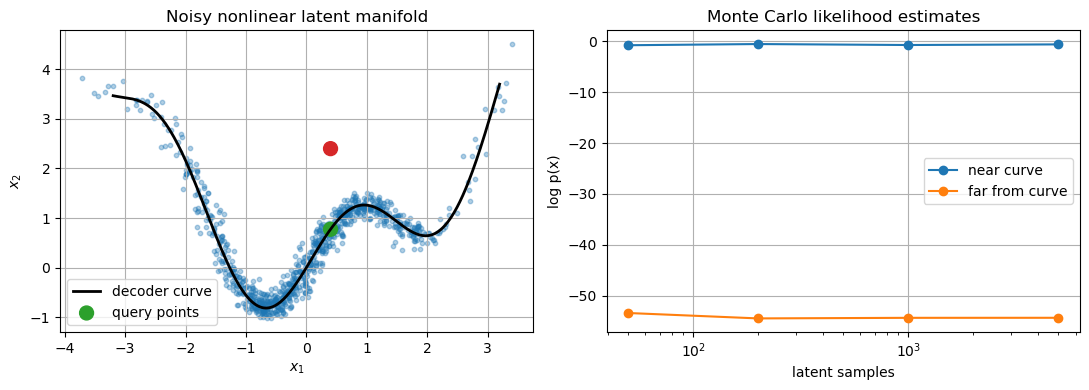

In [13]:
def nonlinear_decoder(z):
    """Map a one-dimensional latent variable into a curved two-dimensional manifold."""
    z = np.asarray(z)
    return np.column_stack([z, 0.35 * z ** 2 + np.sin(2.0 * z)])


def sample_nonlinear_latent(generator, n_samples=900, noise_std=0.12):
    """Sample from p(z) p(x | z) using a nonlinear decoder."""
    z = generator.normal(0.0, 1.2, size=n_samples)
    clean = nonlinear_decoder(z)
    noisy = clean + generator.normal(0.0, noise_std, size=clean.shape)
    return noisy, z


def monte_carlo_log_likelihood(points, n_latent_samples, noise_std, generator):
    """Approximate log p(x) with latent samples from the prior."""
    z_samples = generator.normal(0.0, 1.2, size=n_latent_samples)
    decoded = nonlinear_decoder(z_samples)
    variance = noise_std ** 2

    # Shape (num_points, num_latent_samples, 2): compare each point to each decoded sample.
    residuals = points[:, None, :] - decoded[None, :, :]
    log_conditional = -0.5 * (2 * np.log(2 * np.pi * variance) + np.sum(residuals ** 2, axis=2) / variance)
    return logsumexp(log_conditional, axis=1) - np.log(n_latent_samples)


X_nonlinear, z_nonlinear = sample_nonlinear_latent(rng)
z_curve = np.linspace(-3.2, 3.2, 400)
curve = nonlinear_decoder(z_curve)
query_points = np.array([[0.4, 0.35 * 0.4 ** 2 + np.sin(0.8)], [0.4, 2.4]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(X_nonlinear[:, 0], X_nonlinear[:, 1], s=10, alpha=0.35)
axes[0].plot(curve[:, 0], curve[:, 1], color="black", lw=2, label="decoder curve")
axes[0].scatter(query_points[:, 0], query_points[:, 1], c=["tab:green", "tab:red"], s=100, label="query points")
axes[0].set(title="Noisy nonlinear latent manifold", xlabel="$x_1$", ylabel="$x_2$")
axes[0].legend()

sample_sizes = np.array([50, 200, 1000, 5000])
ll_estimates = np.vstack([
    monte_carlo_log_likelihood(query_points, int(k), 0.12, np.random.default_rng(SEED + int(k)))
    for k in sample_sizes
])
axes[1].plot(sample_sizes, ll_estimates[:, 0], marker="o", label="near curve")
axes[1].plot(sample_sizes, ll_estimates[:, 1], marker="o", label="far from curve")
axes[1].set_xscale("log")
axes[1].set(title="Monte Carlo likelihood estimates", xlabel="latent samples", ylabel="log p(x)")
axes[1].legend()
plt.tight_layout()

print("Rows are sample sizes; columns are near-curve and far-from-curve points.")
print(np.round(ll_estimates, 2))


## 9. Discrete decoder outputs and dequantization

Deep latent-variable models often generate non-Gaussian data. Binary data use Bernoulli outputs, categorical data use softmax outputs, and quantized continuous data can be dequantized by adding uniform noise before density modelling.


Binary probabilities at z=0.8: [0.668 0.354 0.64  0.336 0.364 0.698]
Binary sample: [1 0 0 0 1 1]
Categorical probabilities at z=0.8: [0.331 0.1   0.378 0.191]
Categorical sample: 0


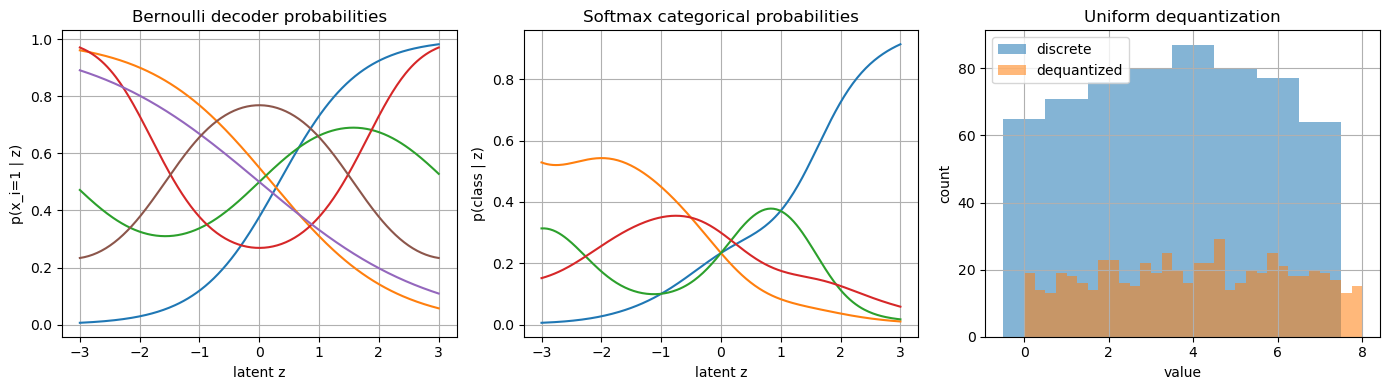

In [14]:
def sigmoid(a):
    """Numerically stable logistic sigmoid for Bernoulli probabilities."""
    return 1.0 / (1.0 + np.exp(-a))


def softmax(logits, axis=-1):
    """Convert logits to categorical probabilities."""
    shifted = logits - np.max(logits, axis=axis, keepdims=True)
    probabilities = np.exp(shifted)
    return probabilities / probabilities.sum(axis=axis, keepdims=True)


def bernoulli_decoder(z):
    """Toy decoder returning probabilities for six binary variables."""
    logits = np.column_stack([
        1.5 * z - 0.5,
        -1.0 * z + 0.2,
        0.8 * np.sin(z),
        0.5 * z ** 2 - 1.0,
        -0.7 * z,
        1.2 * np.cos(z),
    ])
    return sigmoid(logits)


def categorical_decoder(z):
    """Toy decoder returning probabilities for a four-class one-hot variable."""
    logits = np.column_stack([z, -0.5 * z, np.sin(1.5 * z), np.ones_like(z) * 0.25])
    return softmax(logits, axis=1)


z_grid = np.linspace(-3.0, 3.0, 250)
bernoulli_probs = bernoulli_decoder(z_grid)
categorical_probs = categorical_decoder(z_grid)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(z_grid, bernoulli_probs)
axes[0].set(title="Bernoulli decoder probabilities", xlabel="latent z", ylabel="p(x_i=1 | z)")
axes[1].plot(z_grid, categorical_probs)
axes[1].set(title="Softmax categorical probabilities", xlabel="latent z", ylabel="p(class | z)")

# Dequantization turns discrete bins into continuous intervals.
quantized = rng.integers(0, 8, size=600)
dequantized = quantized + rng.uniform(0.0, 1.0, size=len(quantized))
axes[2].hist(quantized, bins=np.arange(-0.5, 8.5, 1.0), alpha=0.55, label="discrete")
axes[2].hist(dequantized, bins=np.linspace(0, 8, 33), alpha=0.55, label="dequantized")
axes[2].set(title="Uniform dequantization", xlabel="value", ylabel="count")
axes[2].legend()
plt.tight_layout()

z0 = np.array([0.8])
binary_prob = bernoulli_decoder(z0)[0]
category_prob = categorical_decoder(z0)[0]
binary_sample = rng.binomial(1, binary_prob)
category_sample = rng.choice(len(category_prob), p=category_prob)

print("Binary probabilities at z=0.8:", np.round(binary_prob, 3))
print("Binary sample:", binary_sample)
print("Categorical probabilities at z=0.8:", np.round(category_prob, 3))
print("Categorical sample:", category_sample)